In [2]:
import numpy as np
import soundfile as sf
import pyworld as pw
import librosa
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio, display
from pathlib import Path
import sys

# Add src to path to import baseline
PROJECT_ROOT = Path.cwd().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.baseline.baseline import Baseline
from src.baseline.experiment_baseline import build_envelope_codebook,apply_codebook_envelopes
from src.analysis.visualize import plot_spectrograms


In [4]:

# 1) Provide paths

# Define paths
source_audio_path = PROJECT_ROOT / "data/voice/forte/f1_long_forte_a.wav"
target_audio_path = PROJECT_ROOT / "data/ddsp_data/raw_audio/IV. Double Presto.wav"
output_dir = PROJECT_ROOT / "data" / "baseline_outputs"
output_dir.mkdir(exist_ok=True)

# 2) Build codebook from violin
codebook, sr, n_fft, hop = build_envelope_codebook(
    target_audio_path,
    sr=16000,
    n_fft=2048,
    hop=256,
    midi_bin_size=1.0,
    cep_lifter=40,
    min_conf=0.7,
)
print(f"Codebook bins: {len(codebook)}")

# 3) Apply to voice
out_path = output_dir / f"baseline_{source_audio_path.stem}.wav"
y, sr = apply_codebook_envelopes(
    source_audio_path,
    codebook,
    sr=sr,
    n_fft=n_fft,
    hop=hop,
    midi_bin_size=1.0,
    cep_lifter=40,
    min_conf=0.7,
    smooth_time=5,
)

# 4) Save
sf.write(out_path, y, sr)
print("Wrote:", out_path)

Codebook bins: 20
Wrote: /m/home/home3/37/thieun1/unix/Project/final_project/data/baseline_outputs/baseline_f1_long_forte_a.wav


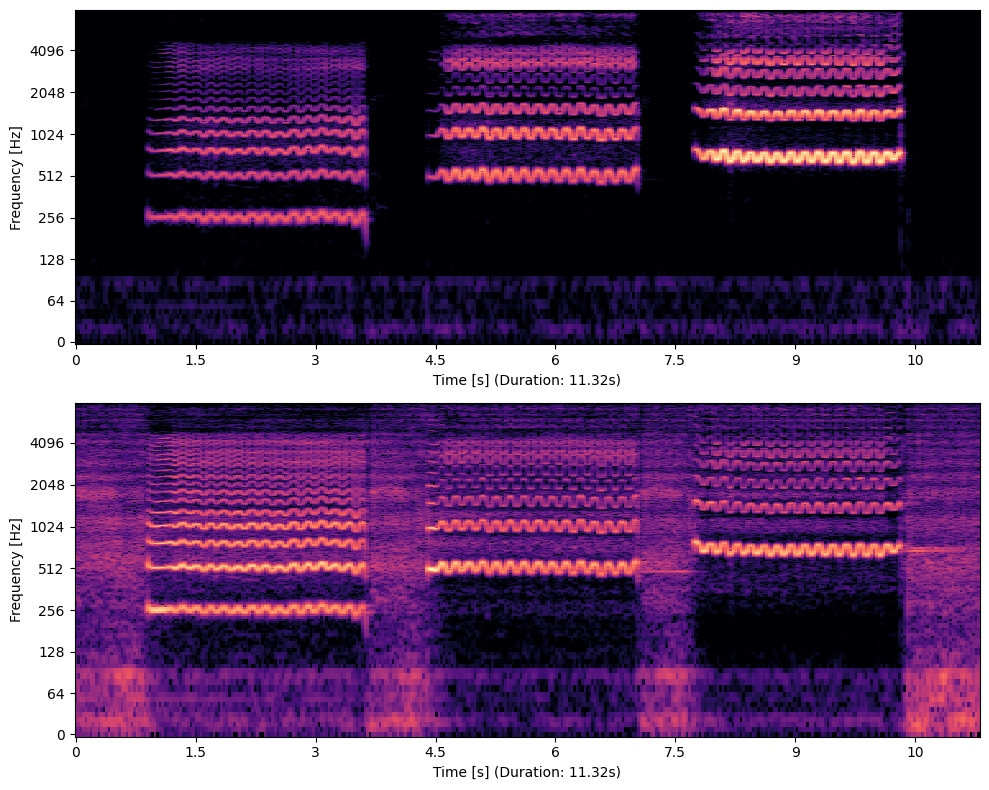

In [6]:
display(Audio(y, rate=sr))
# Plot spectrograms
baseline = Baseline(sample_rate = sr)
y_src,sr = baseline.load_audio(path = source_audio_path)
plot_spectrograms([y_src, y], sr)